## Python for Data Analysis Practical Activity - U.S. Budget

### U.S. Budget: Where the Money Went

This project uses Matplotlib to reveal how U.S. federal spending changed from 1962 to 2018. 
We look at how priorities shifted over time and what the numbers mean today after adjusting for inflation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('us_budget.csv')
df.head()

,Unnamed: 0,Department or Unit,Fiscal Year,President,Budget Dollars,Budget Dollars (Inflation Adjusted)
0,0,Legislative Branch,1962,John F. Kennedy,196000000,"1,629,701,060"
1,1,Judicial Branch,1962,John F. Kennedy,57000000,"473,943,675"
2,2,Department of Agriculture,1962,John F. Kennedy,6437000000,"53,522,376,126"
3,3,Department of Commerce,1962,John F. Kennedy,215000000,"1,787,682,285"
4,4,Department of Defense--Military Programs,1962,John F. Kennedy,50111000000,"416,663,009,172"


In [3]:
df.shape

(1710, 6)

The dataset has:
- 1710 rows
- 6 columns

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1710 entries, 0 to 1709
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Unnamed: 0                           1710 non-null   int64 
 1   Department or Unit                   1710 non-null   object
 2   Fiscal Year                          1710 non-null   int64 
 3   President                            1710 non-null   object
 4   Budget Dollars                       1710 non-null   int64 
 5   Budget Dollars (Inflation Adjusted)  1710 non-null   object
dtypes: int64(3), object(3)
memory usage: 80.3+ KB


##### 1. Plot a bar chart showing the budget allocation for the top 5 departments in 1962.

In [7]:
# Create a bar chart with the created DataFrame top_5_departments to display the budget allocation for these top 5 departments 
# using the following parameters :
# Figuresize : 10 by 6
# Colors : Defined in notebook
# Title : Top 5 U.S. Departments by Budget Allocation in 1962
# xlabel : Department
# ylabel : Budget (in Millions)
# Rotate the x-label by 45 degrees to ensure better readability, then use fig.tight_layout() to ensure everything fits perfectly.

In [8]:
data_1962 = df[df['Fiscal Year'] == 1962]
# # Select the top 5 departments by budget
top_5_departments = data_1962.nlargest(5, 'Budget Dollars')

In [9]:
top_5_departments.head()

,Unnamed: 0,Department or Unit,Fiscal Year,President,Budget Dollars,Budget Dollars (Inflation Adjusted)
4,4,Department of Defense--Military Programs,1962,John F. Kennedy,50111000000,"416,663,009,172"
27,27,Social Security Administration,1962,John F. Kennedy,14365000000,"119,442,121,026"
15,15,Department of the Treasury,1962,John F. Kennedy,8474000000,"70,459,626,424"
2,2,Department of Agriculture,1962,John F. Kennedy,6437000000,"53,522,376,126"
16,16,Department of Veterans Affairs,1962,John F. Kennedy,5608000000,"46,629,405,828"


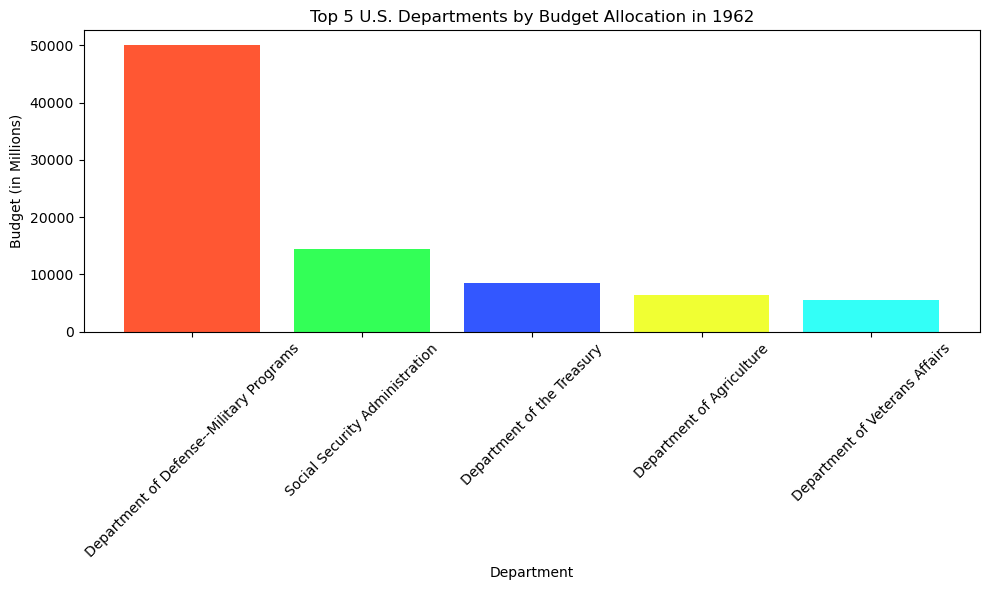

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#FF5733', '#33FF57', '#3357FF', '#F0FF33', '#33FFF7']

# Plotting
ax.bar(top_5_departments['Department or Unit'], top_5_departments['Budget Dollars'] / 1e6, color= colors)

# Adding title and labels
ax.set_title('Top 5 U.S. Departments by Budget Allocation in 1962')
ax.set_xlabel('Department')
ax.set_ylabel('Budget (in Millions)')

# Rotate x-axis labels
ax.set_xticks(top_5_departments['Department or Unit'])
ax.set_xticklabels(top_5_departments['Department or Unit'],rotation = 45)
# Adjust layout
plt.tight_layout()
# Save the figure
plt.savefig("images/Top_5_US_Departments_by_Budget_Allocation_in_1962.png")

##### 2. Plot the Proportion of the Department of Defense's Budget Relative to the Total Federal Budget for Each Fiscal Year from 1962 to 2018

In [11]:
# Plot the Proportion of the Department of Defense's Budget Relative to the Total Federal Budget for Each Fiscal Year from 1962 to 2018
# Use the created DataFrmae combined_budget (which combines the inflation adjusted budget for the defense department and other departments)
# to plot a stacked bar chart using the following parameters:

# Figure size : 10 by 6
# Colors : blue and lightgray
# Title : Proportion of Department of Defense vs. Other Departments (1962-2018), fontsize=16
# xlabel : Fiscal Year, fontsize=12
# ylabel : Budget Dollars (Inflation Adjusted), fontsize=12
# Legend Title : Department, loc=upper left
# Finish by displaying your plot to see the budget proportions over time.

In [12]:
df['Budget Dollars (Inflation Adjusted)'] = df['Budget Dollars (Inflation Adjusted)'].str.replace(',', '').astype(float)

In [13]:
defense_budget = df[df['Department or Unit'] == 'Department of Defense--Military Programs']

# Calculate total budget by fiscal year
total_budget = df.groupby('Fiscal Year')['Budget Dollars (Inflation Adjusted)'].sum()

# # Extract Defense budget per year and calculate other departments' budgets
defense_budget_by_year = defense_budget.set_index('Fiscal Year')['Budget Dollars (Inflation Adjusted)']
other_budget_by_year = total_budget - defense_budget_by_year

# # Combine for plotting
combined_budget = pd.DataFrame({
    'Defense Budget': defense_budget_by_year,
    'Other Departments': other_budget_by_year
})

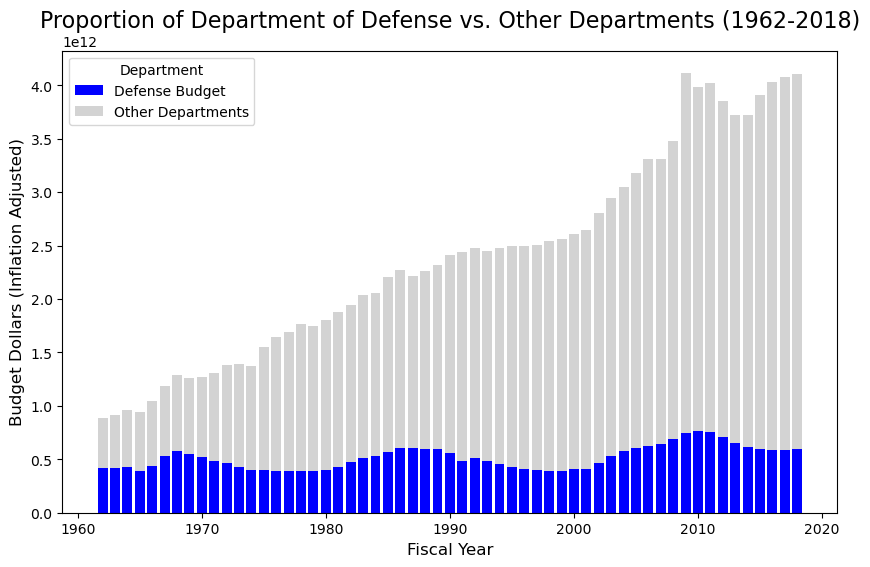

In [14]:
# # Plot 
fig, ax = plt.subplots(figsize=(10, 6))

# Manually plot the stacked bar chart using matplotlib
ax.bar(combined_budget.index, combined_budget['Defense Budget'], color='blue', label='Defense Budget')
ax.bar(combined_budget.index, combined_budget['Other Departments'], bottom=combined_budget['Defense Budget'], color='lightgray', label='Other Departments')

# Set titles and labels
ax.set_title("Proportion of Department of Defense vs. Other Departments (1962-2018)", fontsize=16)
ax.set_xlabel("Fiscal Year", fontsize=12)
ax.set_ylabel("Budget Dollars (Inflation Adjusted)", fontsize=12)

# Add legend
ax.legend(title="Department", loc='upper left')
# Save the figure
plt.savefig("images/Proportion_Departments-1962-2018.png")

##### 3. Compare the original budget values with the inflation-adjusted values to discuss the impact of inflation over time.

In [15]:
# Compare the original budget values with the inflation-adjusted values to discuss the impact of inflation over time.

# In this exercise, you'll create a clear visualization that compares the original and inflation-adjusted budget values by fiscal year. 
# You will be using Matplotlib's object-oriented interface to create two vertically aligned subplots sharing a common x-axis figure size of 12 by 10.

# Subplot 1 will display the original budget values with a bar chart in skyblue.
# Add a title: Original Budget Dollars by Fiscal Year
# Label the y-axis as: Budget Dollars
# Subplot 2 will showcase the inflation-adjusted budget values with a bar chart in salmon.
# Add a title: Inflation Adjusted Budget Dollars by Fiscal Year
# Label the y-axis as: Inflation Adjusted Budget Dollars
# Rotate the x-axis labels by 45 degrees, and label the x-axis as: Fiscal Year
# Finally, apply tight_layout() to ensure the layout is well-adjusted and clear.

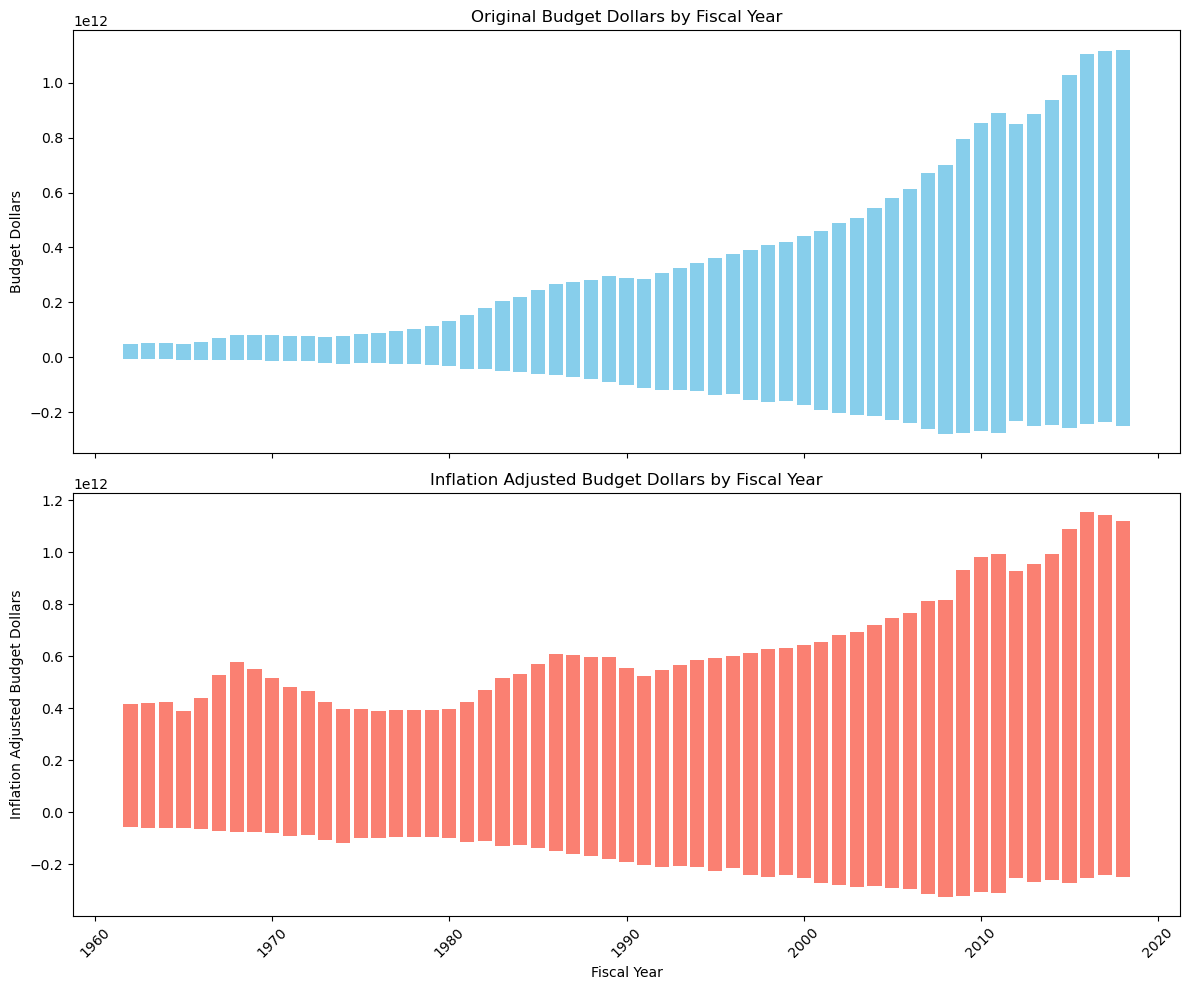

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Original Budget Plot
ax[0].bar(df['Fiscal Year'], df['Budget Dollars'], color='skyblue')
ax[0].set_title('Original Budget Dollars by Fiscal Year')
ax[0].set_ylabel('Budget Dollars')
ax[0].tick_params(axis='x', rotation=45)

# Inflation Adjusted Budget Plot
ax[1].bar(df['Fiscal Year'], df['Budget Dollars (Inflation Adjusted)'], color='salmon')
ax[1].set_title('Inflation Adjusted Budget Dollars by Fiscal Year')
ax[1].set_ylabel('Inflation Adjusted Budget Dollars')
ax[1].tick_params(axis='x', rotation=45)

plt.xlabel('Fiscal Year')
plt.tight_layout()
# Save the figure
plt.savefig("images/Inflation_Adjusted_Budget_Dollars_by_Fiscal_Year.png")

##### 5. Visualize the Proportion of Each Department's Budget Relative to the Total Budget using Stacked Bar Charts

In [17]:
# Visualize the Proportion of Each Department's Budget Relative to the Total Budget using Stacked Bar Charts
# Create a stacked bar chart with the created DataFrame pivot_data by iterating over the departments and stacking the bars and adjusting the bottom 
# parameter to accumulate the heights. Use the following parameters for the plot :

# Figure size : 12 by 8
# Title : Proportion of Each Department's Budget Relative to Total Budget
# xlabel : Fiscal Year
# ylabel : Proportion of Total Budget
# Legend Title : Department or Unit
# Ensure that your x-axis labels are rotated at 45 degrees for readability. Lastly, apply the tight_layout() function to fine-tune the layout before displaying the plot.

In [18]:
# Calculate the total budget
total_budget = df['Budget Dollars'].sum()
# Calculate proportions for each department
df['Proportion'] = df['Budget Dollars'] / total_budget
# Pivot the data for stacked bar chart
pivot_data = df.pivot_table(index='Fiscal Year', columns='Department or Unit', values='Proportion', aggfunc='sum')

fiscal_years = pivot_data.index
departments = pivot_data.columns

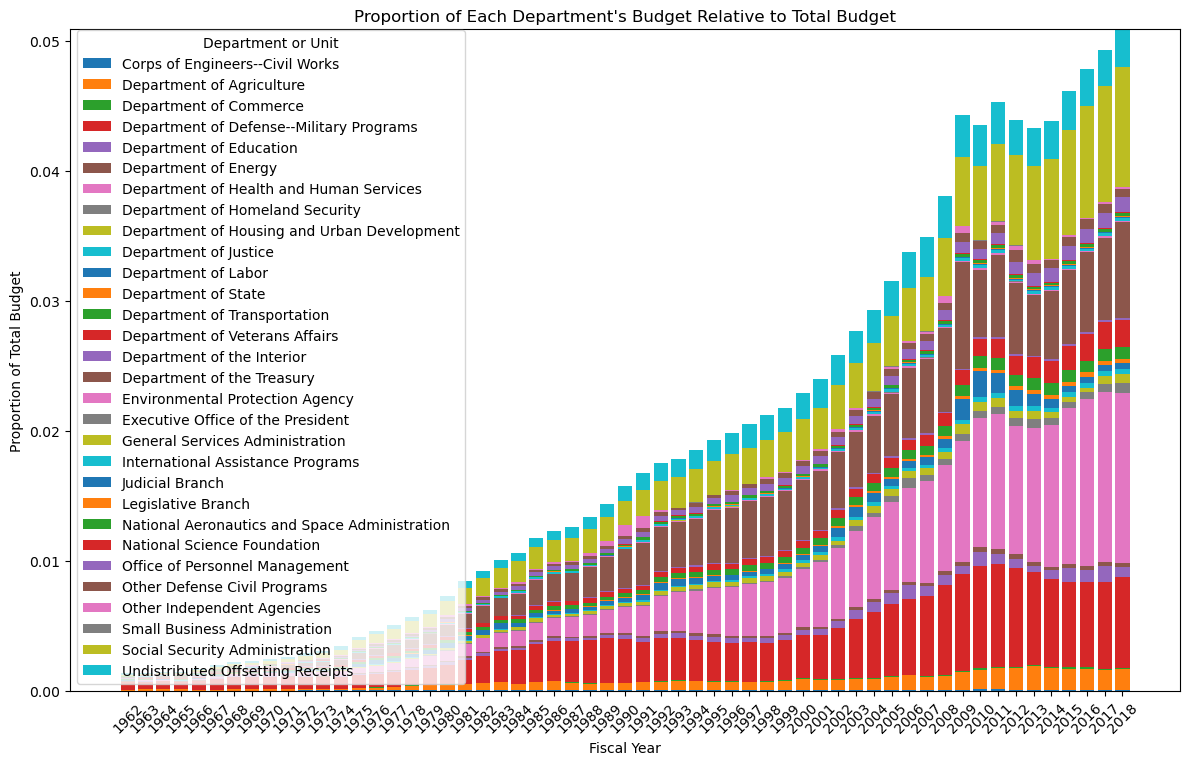

In [19]:
# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Initialize bottom values
bottom_values = [0] * len(fiscal_years)

# Plot each department as a stacked bar
for department in departments:
    ax.bar(fiscal_years, pivot_data[department], bottom=bottom_values, label=department)
    bottom_values = [i + j for i, j in zip(bottom_values, pivot_data[department])]

# Adding labels and title
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Proportion of Total Budget')
ax.set_title('Proportion of Each Department\'s Budget Relative to Total Budget')
ax.legend(title='Department or Unit')
ax.set_xticks(fiscal_years)
ax.set_xticklabels(fiscal_years, rotation=45)

# Adjust layout
plt.tight_layout()
# Save the figure
plt.savefig("images/Proportion_of_Depart_Budget_Relative_Total_Budget.png")

##### 6. Plot a donut chart that shows the proportions of the total federal budget allocated to the Executive, Legislative, and Judicial branches.

In [20]:
branches = ['Executive Office of the President', 'Legislative Branch', 'Judicial Branch']
df_branches = df[df['Department or Unit'].isin(branches)]

# Calculate the total budget for each branch
branch_totals = df_branches.groupby('Department or Unit')['Budget Dollars'].sum()

# Calculate proportions
total_budget = branch_totals.sum()
proportions = branch_totals / total_budget

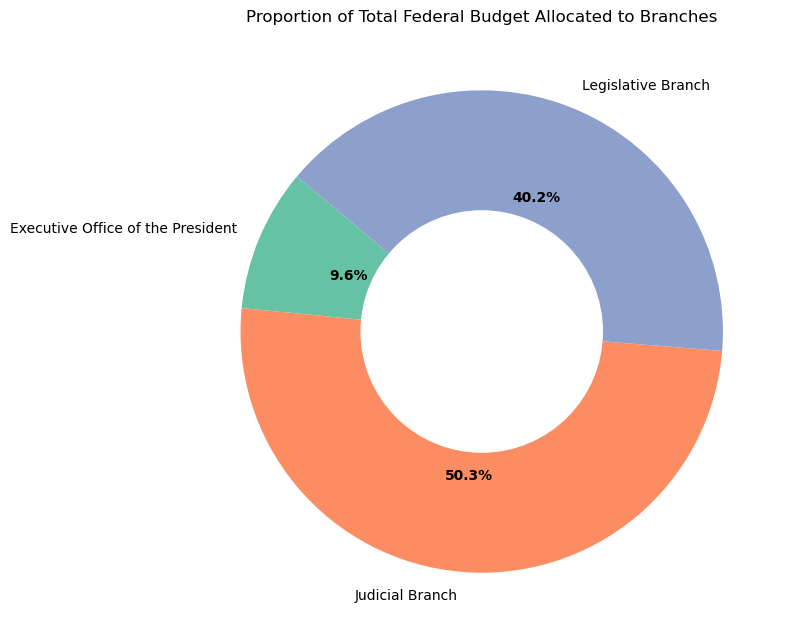

In [21]:
# Plotting the donut chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(aspect="equal"))
color = plt.get_cmap('Set2').colors

# Plot the wedge chart
wedges, texts, autotexts = ax.pie(proportions, labels=proportions.index, autopct='%1.1f%%', startangle=140, colors=color)

# Draw a white circle at the center to create the donut effect
centre_circle = plt.Circle((0, 0), 0.5, color='white', fc='white')
fig.gca().add_artist(centre_circle)

# Formatting the plot
ax.set_title('Proportion of Total Federal Budget Allocated to Branches')
plt.setp(autotexts, size=10, weight="bold")

# Adjust layout
plt.tight_layout()
# Save the figure
plt.savefig("images/Proportion_of_Total_Federal_Budget_Allocated_to_Branches.png")

##### 7. Create a Horizontal bar chart comparing the budget amounts (inflation-adjusted) for the most-funded departments.

In [22]:
# Create a Horizontal bar chart comparing the budget amounts (inflation-adjusted) for the most-funded departments.

# Create a horizontal bar chart with the DataFrame top_departments, setting the bars' color to green and a figure size of 10 by 6. 
# Label the x-axis as Budget Dollars (Inflation Adjusted), the y-axis as Department or Unit, and give the chart the title 
# Most-Funded Departments (Inflation Adjusted). Finally, apply tight_layout() to ensure the chart is neatly formatted.

In [23]:
top_departments = df.sort_values('Budget Dollars (Inflation Adjusted)', ascending=False)

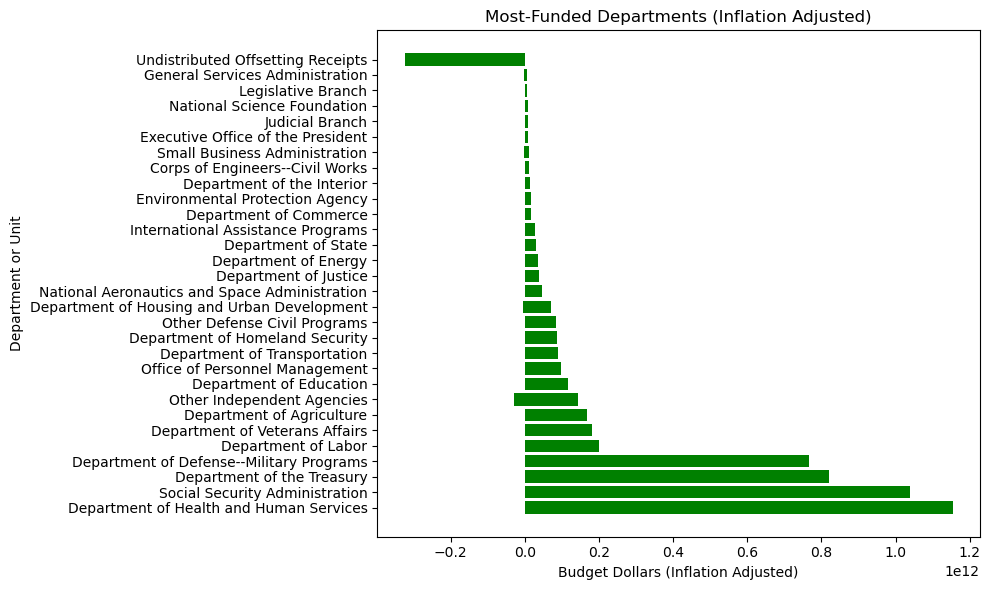

In [24]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Create horizontal bar chart
ax.barh(top_departments['Department or Unit'], top_departments['Budget Dollars (Inflation Adjusted)'], color='green')

# Adding labels and title
ax.set_xlabel('Budget Dollars (Inflation Adjusted)')
ax.set_ylabel('Department or Unit')
ax.set_title('Most-Funded Departments (Inflation Adjusted)')

# Adjust layout
plt.tight_layout()
# Save the figure
plt.savefig("images/Most-Funded_Departments.png")

##### 8. Create a bar chart comparing the budgets. Evaluate the changes in the country's shifting priorities.

In [25]:
# Create a bar chart comparing the budgets. Evaluate the changes in the country's shifting priorities.

# In this exercise, you will analyze and visualize the top five funded departments based on their inflation-adjusted budgets for 
# the years 1962 and 2018. You will use a bar chart to facilitate a direct comparison between the two years, highlighting how funding 
# has changed over time. Using the calculated DataFrames top_2018 and top_1962, create a bar chart to compare the top five departments from both years.

# Figure size : 10 by 6
# Title : Top 5 Funded Departments (Inflation Adjusted) in 1962 vs 2018
# xlabel : Departments
# ylabel : Budget Dollars (Inflation Adjusted)
# bar_width : 0.35
# Adjust the x-ticks to display department names, rotating them by 45 degrees for better readability. 
# Also, include a legend to distinguish between the years. Finally, Use .tight_layout() to ensure the layout is clean and free of overlaps.

In [26]:
df_1962 = df[df['Fiscal Year'] == 1962]
df_2018 = df[df['Fiscal Year'] == 2018]

# Get top 5 departments for each year based on Inflation Adjusted Budget
top_1962 = df_1962.nlargest(5, 'Budget Dollars (Inflation Adjusted)')
top_2018 = df_2018.nlargest(5, 'Budget Dollars (Inflation Adjusted)')

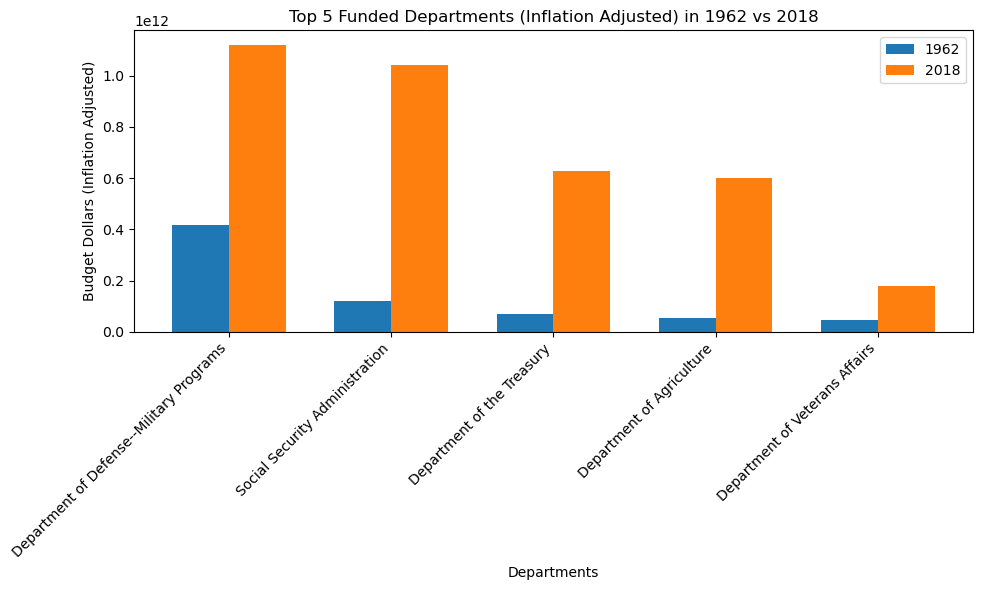

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

# Bar positions for the two groups
bar_width = 0.35
r1 = range(len(top_1962))
r2 = [x + bar_width for x in r1]

# Bar chart for 1962
ax.bar(r1, top_1962['Budget Dollars (Inflation Adjusted)'], width=bar_width, label='1962')

# Bar chart for 2018
ax.bar(r2, top_2018['Budget Dollars (Inflation Adjusted)'], width=bar_width, label='2018')

# Add labels and title
ax.set_xlabel('Departments')
ax.set_ylabel('Budget Dollars (Inflation Adjusted)')
ax.set_title('Top 5 Funded Departments (Inflation Adjusted) in 1962 vs 2018')
ax.set_xticks([r + bar_width / 2 for r in range(len(top_1962))])
ax.set_xticklabels(top_1962['Department or Unit'], rotation=45, ha="right")

# Add legend
ax.legend()

# Show plot
plt.tight_layout()
# Save the figure
plt.savefig("images/Top_5_Funded_Departments_in_1962-vs-2018.png")

##### 9. Who Was the 'Big Spender' President?

In [28]:
# Who Was the 'Big Spender' President?

# Using the created DataFrame sorted_presidents, create a 12 by 8 figure and axis for plotting, then generate a dark blue bar chart, 
# setting the x-axis to the sorted president names and the y-axis to their total budgets. Label the x-axis as President, 
# the y-axis as Total Budget Dollars (Inflation Adjusted), and give the plot a title: Which President Had the Largest Inflation-Adjusted Budget?. 
# Adjust x-tick labels to be readable by rotating them(rotation=45, ha=right), and use .tight_layout to ensure the plot is propoerly laid out. 
# Finally, use idxmax() and max() to find and print the name and amount of the president with the highest budget.

In [29]:
president_totals = df.groupby('President')['Budget Dollars (Inflation Adjusted)'].sum()

# Sort the results to find the top spender
sorted_presidents = president_totals.sort_values(ascending=False)

C:\Users\V110User\AppData\Local\Temp\ipykernel_9308\1157234985.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_presidents.index, rotation=45, ha='right')


The 'Big Spender' President was Barack Obama with a total inflation-adjusted budget of $31,324,471,267,184.00.


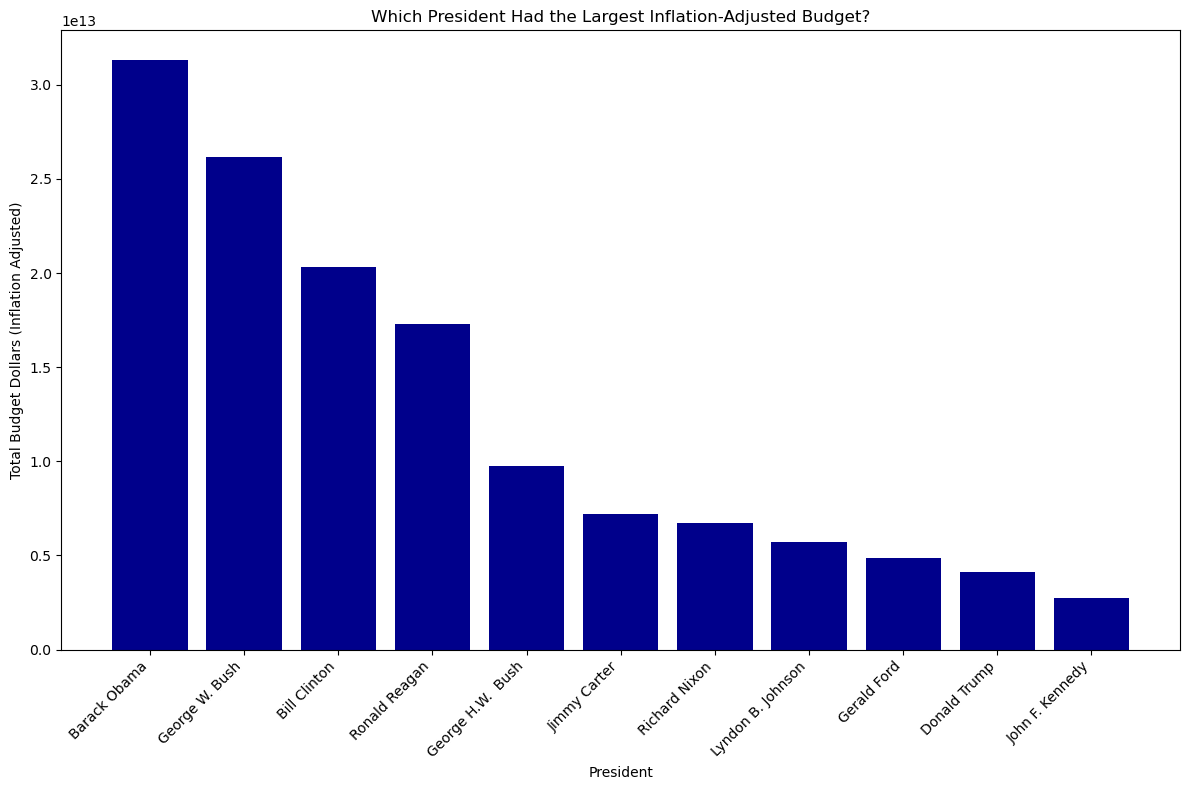

In [30]:
# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Create a bar chart
ax.bar(sorted_presidents.index, sorted_presidents, color='darkblue')

# Adding labels and title
ax.set_xlabel('President')
ax.set_ylabel('Total Budget Dollars (Inflation Adjusted)')
ax.set_title('Which President Had the Largest Inflation-Adjusted Budget?')
ax.set_xticklabels(sorted_presidents.index, rotation=45, ha='right')

# Show plot
plt.tight_layout()
# Save the figure
plt.savefig("images/President_Largest_Budget.png")

# Print the top spender
top_president = sorted_presidents.idxmax()
top_amount = sorted_presidents.max()
print(f"The 'Big Spender' President was {top_president} with a total inflation-adjusted budget of ${top_amount:,.2f}.")


##### 10. Plot the percentage change in inflation-adjusted budget dollars between presidential administrations for Agriculture and determine the president with the largest budget increase

In [31]:
# Plot the percentage change in inflation-adjusted budget dollars between presidential administrations for Agriculture and determine the
# president with the largest budget increase
# Using the DataFrame df_agriculture created in your notebook, plot the percentage changes over fiscal years for each president.

# Figure size : 12 by 6
# Marker : o
# Title : Percentage Change in Inflation-Adjusted Budget for the Department of Agriculture by President
# xlabel : Fiscal Year
# ylabel : Percentage Change in Budget Dollars (Inflation Adjusted)
# Legend Title : President
# Finally, add grid lines and display the plot using .tight_layout().

In [32]:
df_agriculture = df[df['Department or Unit'] == 'Department of Agriculture']

# Calculate the percentage change in inflation-adjusted budget dollars between presidential administrations
df_agriculture = df_agriculture.sort_values(['President', 'Fiscal Year'])
df_agriculture['Percentage Change'] = df_agriculture.groupby('President')['Budget Dollars (Inflation Adjusted)'].pct_change() * 100

# Remove NaN values that result from pct_change
df_agriculture = df_agriculture.dropna(subset=['Percentage Change'])

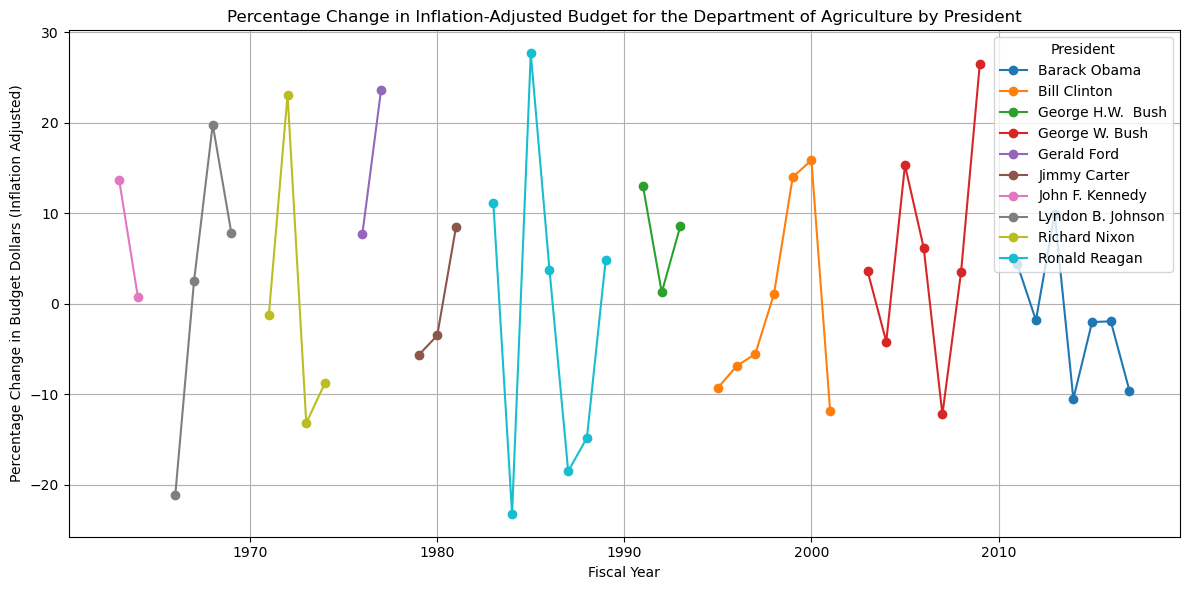

In [33]:
# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Create a bar chart for percentage change
for president in df_agriculture['President'].unique():
    president_data = df_agriculture[df_agriculture['President'] == president]
    ax.plot(president_data['Fiscal Year'], president_data['Percentage Change'], marker='o', label=president)

# Adding labels and title
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Percentage Change in Budget Dollars (Inflation Adjusted)')
ax.set_title('Percentage Change in Inflation-Adjusted Budget for the Department of Agriculture by President')
ax.legend(title='President')
ax.grid(True)

# Show plot
plt.tight_layout()
# Save the figure
plt.savefig("images/Percentage_Change_Dept_Agriculture_by_President.png")

In [35]:
# ### Credits
# - ITONlinelearning
# - Datawars